# ধাপ ১: ডাটা পরিচিতি ও প্রাথমিক পর্যবেক্ষণ (Data Exploration & Cleaning)

এই ধাপে আমরা ডাটাসেটটি লোড করব এবং এর গঠন (Shape), ডাটার ধরন (Data Types) এবং কোনো মিসিং ভ্যালু (Missing Values) আছে কি না তা পরীক্ষা করব। 
একই সাথে এই প্রজেক্টের টার্গেট ভ্যারিয়েবল এবং ইনপুট ফিচারগুলো সনাক্ত করব।

In [34]:
# ১. ডাটা ম্যানিপুলেশন ও প্রসেসিং
import pandas as pd
import numpy as np

# ২. ডাটা ভিজ্যুয়ালাইজেশন (গ্রাফ ও প্লট)
import matplotlib.pyplot as plt
import seaborn as sns

# ৩. ডাটা স্প্লিট ও মডেলিং অ্যালগরিদম
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor as xgb
import time

# ৪. মডেল মূল্যায়ন (Metrics)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ৫. মডেল সেভ ও লোড করা
import joblib

# ৬. এপিআই তৈরি করা
from flask import Flask, request, jsonify

In [35]:
# ৭. ডাটা লোড করা
data = pd.read_csv("solar_weather.csv")
data

,Time,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
0,2017-01-01 00:00:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.00,4,0,1
1,2017-01-01 00:15:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.00,4,0,1
2,2017-01-01 00:30:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.00,4,0,1
3,2017-01-01 00:45:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.00,4,0,1
4,2017-01-01 01:00:00,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.00,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196771,2022-08-31 16:45:00,118,23.7,18.6,1023,57,3.8,0.0,0.0,52,1,780,825,0.95,3,16,8
196772,2022-08-31 17:00:00,82,15.6,18.5,1023,61,4.2,0.0,0.0,60,1,795,825,0.96,3,17,8
196773,2022-08-31 17:15:00,51,8.0,18.5,1023,61,4.2,0.0,0.0,60,1,810,825,0.98,3,17,8
196774,2022-08-31 17:30:00,24,2.1,18.5,1023,61,4.2,0.0,0.0,60,1,825,825,1.00,3,17,8


In [36]:
#ডেটা ইনফরমেশন দেখা
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196776 entries, 0 to 196775
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    196776 non-null  object 
 1   Energy delta[Wh]        196776 non-null  int64  
 2   GHI                     196776 non-null  float64
 3   temp                    196776 non-null  float64
 4   pressure                196776 non-null  int64  
 5   humidity                196776 non-null  int64  
 6   wind_speed              196776 non-null  float64
 7   rain_1h                 196776 non-null  float64
 8   snow_1h                 196776 non-null  float64
 9   clouds_all              196776 non-null  int64  
 10  isSun                   196776 non-null  int64  
 11  sunlightTime            196776 non-null  int64  
 12  dayLength               196776 non-null  int64  
 13  SunlightTime/daylength  196776 non-null  float64
 14  weather_type        

In [37]:
# ডাটার কলাম, টাইপ এবং কোনো মিসিং ভ্যালু আছে কি না ও ডুপলিকেট আছে কিনা তা দেখা
print("Dataset Shape:", data.shape)
print("\nDuplicates :",data.duplicated().sum())
print("\n--- Missing Values ---")
print(data.isnull().sum())

Dataset Shape: (196776, 17)

Duplicates : 0

--- Missing Values ---
Time                      0
Energy delta[Wh]          0
GHI                       0
temp                      0
pressure                  0
humidity                  0
wind_speed                0
rain_1h                   0
snow_1h                   0
clouds_all                0
isSun                     0
sunlightTime              0
dayLength                 0
SunlightTime/daylength    0
weather_type              0
hour                      0
month                     0
dtype: int64


In [38]:
# 'Time' কলামটি ড্রপ করা হচ্ছে কারণ মডেল টেক্সট বুঝতে পারে না এবং 
# 'hour' ও 'month' কলামগুলো দিয়ে সময়ের কাজ হয়ে যাবে।
data = data.drop(columns=['Time'])

# ড্রপ করার পর ডেটাসেটটি কেমন দেখাচ্ছে তা চেক করা
print("Time কলাম ড্রপ করার পর ডেটার বর্তমান অবস্থা:")
data.head()

Time কলাম ড্রপ করার পর ডেটার বর্তমান অবস্থা:


,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
0,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
1,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
2,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
3,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
4,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.0,4,1,1


### ডেটা পর্যবেক্ষণ সমাপ্তি ও ভিজ্যুয়ালাইজেশনের প্রস্তুতি (Data Cleaning Done)

প্রাথমিক পর্যবেক্ষণে দেখা গেছে আমাদের ডাটাসেটটি সম্পূর্ণ পরিষ্কার। 
* ডাটায় কোনো **Missing Values (ফাঁকা ঘর)** নেই।
* কোনো **Duplicate (দ্বৈত)** ডেটা নেই।
* প্রতিটি কলামের **Data Type (ডেটার ধরন)** একদম নিখুঁত আছে (কোথাও কোনো অনাকাঙ্ক্ষিত টেক্সট বা স্ট্রিংয়ের ঝামেলা নেই)।

যেহেতু মেশিন লার্নিং মডেল সরাসরি স্ট্রিং বা তারিখ (Datetime) প্রসেস করতে পারে না এবং আমাদের কাছে সময় নির্দেশ করার জন্য আগে থেকেই `hour` এবং `month` কলামগুলো আছে, তাই আমরা `Time` কলামটি ডেটাসেট থেকে ড্রপ (Drop) করে দিয়েছি। এবং ভিজ্যুয়ালাইজেশন শুরু করছি।

### ভিজ্যুয়ালাইজেশন ১: Correlation Heatmap
এই হিটম্যাপের মাধ্যমে আমরা দেখতে পাবো টার্গেট ভ্যারিয়েবল (`Energy delta[Wh]`)-এর সাথে অন্যান্য ইনপুট ফিচারগুলোর কেমন সম্পর্ক রয়েছে। এটি আমাদের বুঝতে সাহায্য করবে কোন ফিচারগুলো মডেলের জন্য সবচেয়ে বেশি গুরুত্বপূর্ণ।

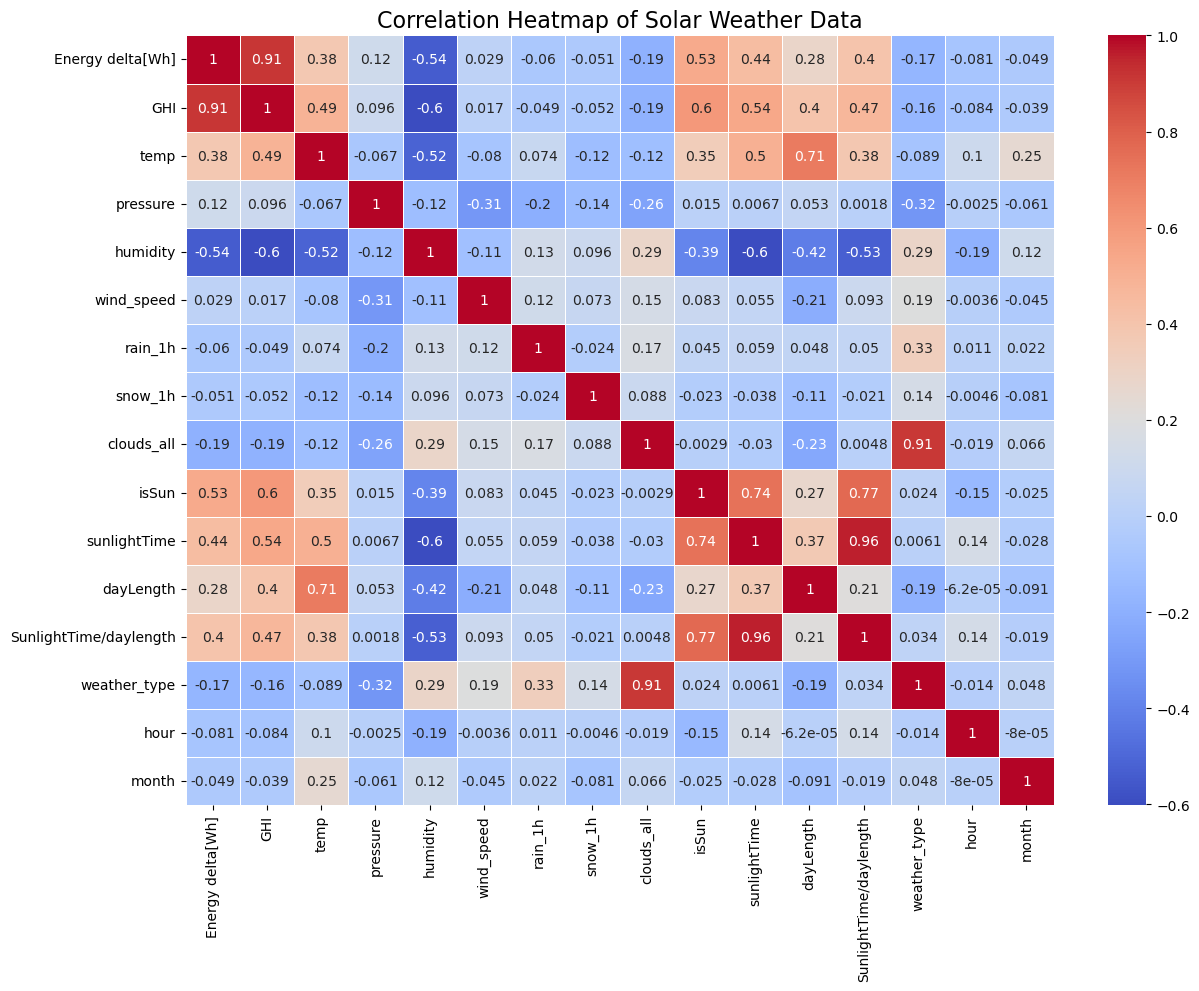

In [39]:
plt.figure(figsize=(14, 10))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths= 0.5)
plt.title('Correlation Heatmap of Solar Weather Data', fontsize=16)
plt.show()

### হিটম্যাপ বিশ্লেষণ (Insights from Correlation Heatmap)

উপরের হিটম্যাপটি থেকে আমাদের টার্গেট ভ্যারিয়েবল (`Energy delta[Wh]`) এবং অন্যান্য ফিচারের পারস্পরিক সম্পর্ক সম্পর্কে বেশ কিছু গুরুত্বপূর্ণ সিদ্ধান্ত নেওয়া যায়:

১. **সবচেয়ে বেশি সম্পর্কিত ফিচার (Most Correlated Feature):** 
`Energy delta[Wh]`-এর সাথে `GHI` (Global Horizontal Irradiance)-এর সবচেয়ে শক্তিশালী পজিটিভ সম্পর্ক (0.91) রয়েছে। অর্থাৎ, সূর্যরশ্মির তীব্রতা যত বাড়ে, বিদ্যুৎ উৎপাদন তত বেশি বৃদ্ধি পায়।

২. **নেতিবাচক সম্পর্ক (Negative Correlation):** 
টার্গেট ভ্যারিয়েবলের সাথে `humidity` (-0.54) এবং `clouds_all` (-0.19)-এর নেতিবাচক বা ঋণাত্মক সম্পর্ক রয়েছে। এটি প্রমাণ করে যে, বাতাসে আর্দ্রতা বা মেঘের পরিমাণ বাড়লে সোলার প্যানেলের বিদ্যুৎ উৎপাদন কমে যায়।

৩. **ফিচার সিলেকশনের ইঙ্গিত (Multicollinearity):** 
ডাটাসেটের কিছু ইনপুট ফিচারের নিজেদের মধ্যে অত্যন্ত শক্তিশালী সম্পর্ক রয়েছে। যেমন: `clouds_all` এবং `weather_type` (0.91) এবং `sunlightTime` ও `SunlightTime/daylength` (0.96)। মডেল ট্রেইনিংয়ের সময় এদের মধ্যে থেকে যে কোনো একটি ফিচার বাদ দিলে (Removing correlated features) মডেল ওভারফিটিং থেকে রক্ষা পাবে এবং পারফরম্যান্স উন্নত হবে।

### ভিজ্যুয়ালাইজেশন ২: Impact of GHI and Clouds on Energy
ডাটাসেটে প্রায় ২ লাখ সারি (Rows) থাকায় স্ক্যাটার প্লটে "Overplotting"-এর সমস্যা হতে পারে। তাই গ্রাফের প্যাটার্ন আরও স্পষ্টভাবে বোঝার জন্য আমরা সম্পূর্ণ ডেটা থেকে ৫,০০০ ডেটার একটি র‍্যান্ডম স্যাম্পল (Random Sample) নিয়ে এই স্ক্যাটার প্লটটি তৈরি করছি। 

এখানে `GHI` (রোদ) এবং `Energy` (বিদ্যুৎ)-এর সম্পর্কের ওপর মেঘের (`clouds_all`) প্রভাব দেখানো হয়েছে।

In [40]:
sampled_data = data.sample(n=5000, random_state=42)

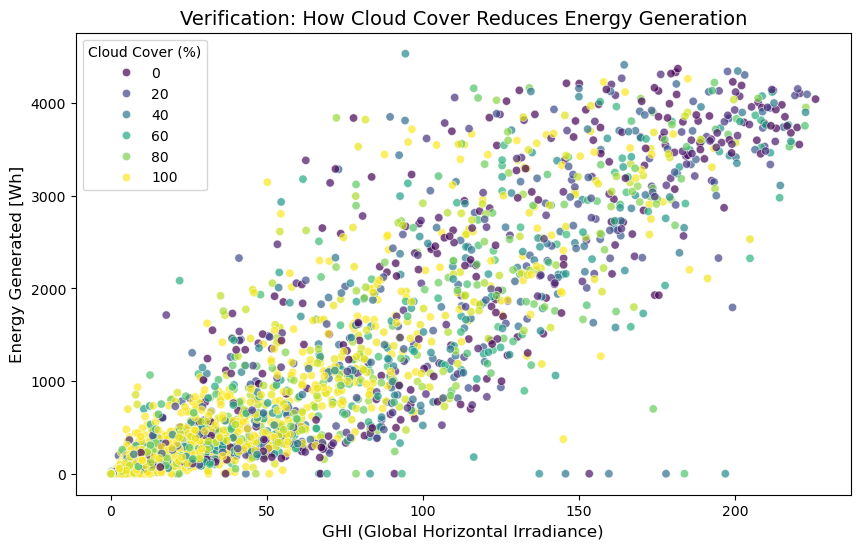

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sampled_data, x='GHI', y='Energy delta[Wh]', hue='clouds_all', palette='viridis', alpha=0.7)
plt.title('Verification: How Cloud Cover Reduces Energy Generation', fontsize=14)
plt.xlabel('GHI (Global Horizontal Irradiance)', fontsize=12)
plt.ylabel('Energy Generated [Wh]', fontsize=12)

plt.legend(title='Cloud Cover (%)')
plt.show()

### স্ক্যাটার প্লট বিশ্লেষণ (Insights from Scatter Plot)

এই গ্রাফটি আমাদের ডেটাসেটের একটি অত্যন্ত গুরুত্বপূর্ণ প্যাটার্ন তুলে ধরে এবং ব্রিফের একটি প্রশ্নের সরাসরি উত্তর দেয়: *"মেঘের কারণে যে বিদ্যুৎ উৎপাদন কমে যায়, তা কীভাবে প্রমাণ করবে?"*

১. **GHI এবং শক্তির পজিটিভ সম্পর্ক:** গ্রাফের সাধারণ ট্রেন্ডটি ঊর্ধ্বমুখী। অর্থাৎ, GHI (সূর্যরশ্মির তীব্রতা) বৃদ্ধির সাথে সাথে এনার্জি বা বিদ্যুৎ উৎপাদন রৈখিকভাবে বৃদ্ধি পায়।
২. **মেঘের নেতিবাচক প্রভাব (Impact of Clouds):** কালার স্কেল (Hue) অনুযায়ী, গাঢ় বেগুনি বিন্দুগুলো নির্দেশ করে পরিষ্কার আকাশ (০% মেঘ) এবং হলুদ বিন্দুগুলো নির্দেশ করে মেঘলা আকাশ (১০০% মেঘ)। 
৩. **চূড়ান্ত প্রমাণ:** গ্রাফে পরিষ্কার দেখা যাচ্ছে যে, একটি নির্দিষ্ট লেভেলের GHI থাকা সত্ত্বেও, গাঢ় বেগুনি বিন্দুগুলো (মেঘমুক্ত আকাশ) সবসময় গ্রাফের উপরের দিকে (উচ্চ বিদ্যুৎ উৎপাদন) অবস্থান করছে। অন্যদিকে, হলুদ বিন্দুগুলো (মেঘলা আকাশ) নিচের দিকে নেমে গেছে। এটি গাণিতিক ও প্র্যাকটিক্যালি প্রমাণ করে যে, মেঘের আবরণ সোলার প্যানেলের বিদ্যুৎ উৎপাদন সরাসরি কমিয়ে দেয়।

### ভিজ্যুয়ালাইজেশন ৩: Boxplot for Outlier Detection
ডেটাতে কোনো অস্বাভাবিক মান (Outliers) আছে কি না, তা সনাক্ত করার জন্য আমরা টার্গেট ভ্যারিয়েবল এবং গুরুত্বপূর্ণ ফিচারগুলোর বক্সপ্লট (Boxplot) তৈরি করব।

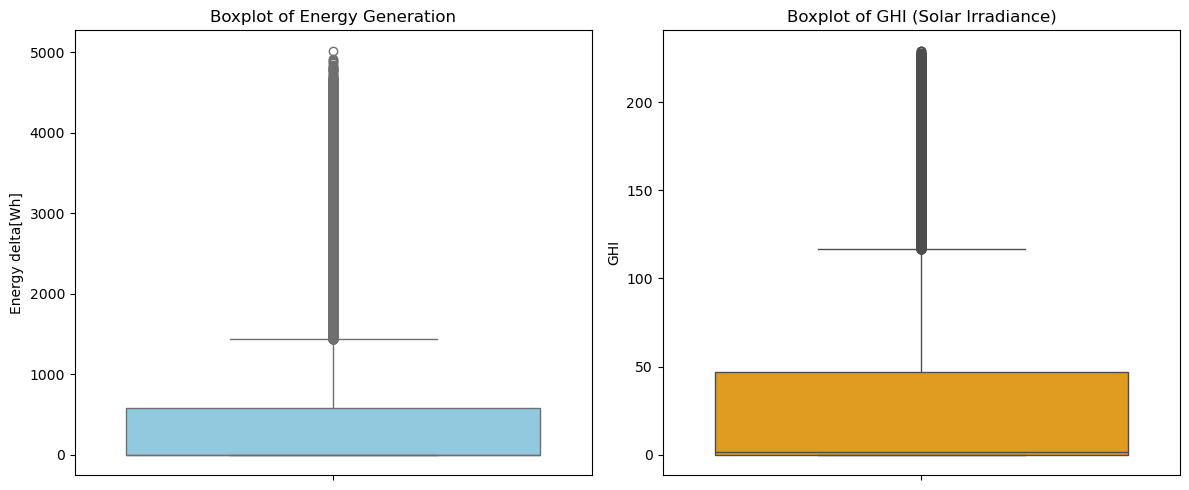

In [42]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=data['Energy delta[Wh]'], color='skyblue')
plt.title('Boxplot of Energy Generation')

plt.subplot(1, 2, 2)
sns.boxplot(y=data['GHI'], color='orange')
plt.title('Boxplot of GHI (Solar Irradiance)')

plt.tight_layout()
plt.show()

### আউটলায়ার সনাক্তকরণ ও বিশ্লেষণ (Outlier Detection using Boxplots)

ব্রিফের প্রশ্ন অনুযায়ী ডেটাতে আউটলায়ার সনাক্ত করার জন্য আমরা **Boxplot** ব্যবহার করেছি। 

**পর্যবেক্ষণ ও সিদ্ধান্ত:**
বক্সপ্লটে `Energy delta[Wh]` এবং `GHI` উভয়ের ক্ষেত্রেই উপরের দিকে প্রচুর আউটলায়ার (কালো বিন্দু) দেখা যাচ্ছে। গাণিতিকভাবে এগুলো আউটলায়ার মনে হলেও, ডোমেইন নলেজ (Domain Knowledge) থেকে আমরা জানি যে এগুলো কোনো ত্রুটিপূর্ণ ডেটা (Erroneous data) নয়। 

সোলার প্যানেলের ক্ষেত্রে দিনের প্রায় অর্ধেক সময় (রাত) উৎপাদন শূন্য থাকে, যা ডেটার গড় (Mean) ও কোয়ার্টাইলকে (Quartile) অনেক নিচে নামিয়ে আনে। ফলে দুপুরের পরিষ্কার আকাশে সর্বোচ্চ রোদ (Peak GHI) ও সর্বোচ্চ বিদ্যুৎ উৎপাদনের ডেটাগুলোকে বক্সপ্লট আউটলায়ার হিসেবে চিহ্নিত করেছে। 

যেহেতু এই ডেটাগুলো বাস্তব এবং সোলার প্যানেলের সর্বোচ্চ ক্ষমতার নির্দেশক, তাই মডেল ট্রেইনিংয়ের জন্য আমরা এই **আউটলায়ারগুলো ড্রপ (Drop) করব না**। বিশেষ করে Random Forest ও XGBoost-এর মতো নন-লিনিয়ার মডেলগুলো এ ধরনের স্কিউড (Skewed) ডেটা দক্ষতার সাথেই হ্যান্ডেল করতে পারে।

# ধাপ ৩: ফিচার ইঞ্জিনিয়ারিং (Feature Engineering)

**ব্রিফের প্রশ্ন:** *"Suggest three feature engineering techniques."*

মডেলের প্রেডিকশন ক্ষমতা বা পারফরম্যান্স বৃদ্ধি করার জন্য কাঁচা ডেটা (Raw Data) থেকে নতুন এবং অর্থবহ ফিচার তৈরি করার প্রক্রিয়াটিই হলো ফিচার ইঞ্জিনিয়ারিং। আমাদের সোলার প্যানেলের এনার্জি প্রেডিকশন মডেলটিকে আরও নির্ভুল করতে আমরা ৩টি প্রফেশনাল ফিচার ইঞ্জিনিয়ারিং টেকনিক প্রয়োগ করব। 

### টেকনিক ১: Interaction Feature (ইন্টারঅ্যাকশন ফিচার তৈরি)
অনেক সময় দুটি আলাদা ফিচারের সম্মিলিত প্রভাব মডেলকে আরও ভালো প্যাটার্ন বুঝতে সাহায্য করে। আমাদের ডেটাসেটে `temp` (তাপমাত্রা) এবং `humidity` (আর্দ্রতা) রয়েছে। আমরা জানি, অতিরিক্ত গরমের সাথে আর্দ্রতা বেশি থাকলে প্যানেলের কার্যক্ষমতায় একটি মিশ্র প্রভাব পড়ে। তাই আমরা এই দুটি ফিচার গুণ করে **`temp_humidity`** নামে নতুন একটি ইন্টারঅ্যাকশন ফিচার তৈরি করব।

In [43]:
data['temp_humidity'] = data['temp'] * data['humidity']

print("সফলভাবে 'temp_humidity' ফিচারটি তৈরি হয়েছে!")
print("\n  --- নতুন ফিচারের স্যাম্পল ডেটা ---")
data[['temp', 'humidity', 'temp_humidity']].head()

সফলভাবে 'temp_humidity' ফিচারটি তৈরি হয়েছে!

  --- নতুন ফিচারের স্যাম্পল ডেটা ---


,temp,humidity,temp_humidity
0,1.6,100,160.0
1,1.6,100,160.0
2,1.6,100,160.0
3,1.6,100,160.0
4,1.7,100,170.0


### টেকনিক ২: Domain-Specific Feature (ডোমেইন নলেজ ব্যবহার করে ফিচার তৈরি)
সোলার প্যানেলের ক্ষেত্রে দিনের একটি নির্দিষ্ট সময়ে (সাধারণত সকাল ১০টা থেকে দুপুর ২টা পর্যন্ত) সর্বোচ্চ বিদ্যুৎ উৎপাদিত হয়। মডেল যাতে এই "Peak Hours" বা ব্যস্ততম সময়টুকু সহজে সনাক্ত করতে পারে, সে জন্য আমরা `hour` কলামটি ব্যবহার করে `is_peak_hour` নামে একটি নতুন বাইনারি (0 বা 1) ফিচার তৈরি করব।

In [44]:
data['is_peak_hour'] = data['hour'].apply(lambda x: 1 if 10 <= x <= 14 else 0)

print("সফলভাবে 'is_peak_hour' ফিচারটি তৈরি হয়েছে!")
print("--- নতুন ফিচারের স্যাম্পল ডেটা (ঘণ্টা এবং পিক আওয়ার) ---")

data[['hour', 'is_peak_hour']].sample(10, random_state=42)

সফলভাবে 'is_peak_hour' ফিচারটি তৈরি হয়েছে!
--- নতুন ফিচারের স্যাম্পল ডেটা (ঘণ্টা এবং পিক আওয়ার) ---


,hour,is_peak_hour
110142,7,0
191706,22,0
150704,20,0
188361,2,0
75797,13,1
172776,18,0
67686,1,0
134025,2,0
99145,18,0
86867,20,0


### টেকনিক ৩: Feature Selection (অতিরিক্ত বা Correlated ফিচার বাদ দেওয়া)

**ব্রিফের প্রশ্ন:** *"Why can removing correlated features improve performance?"*

যখন ডাটাসেটের দুটি ইনপুট ফিচারের মধ্যে অত্যন্ত শক্তিশালী সম্পর্ক (High Correlation) থাকে, তখন তারা মডেলে একই তথ্য বারবার প্রদান করে, যাকে Multicollinearity বলে। এর ফলে লিনিয়ার মডেলগুলো কনফিউজড হয়ে যায় এবং ওভারফিটিংয়ের ঝুঁকি বাড়ে। কো-রিলেটেড ফিচার বাদ দিলে ডেটার নয়েজ (Noise) কমে, মডেলের কম্পিউটেশনাল সময় বাঁচে এবং প্রেডিকশন পারফরম্যান্স উন্নত হয়।

আমাদের হিটম্যাপ অনুযায়ী, `sunlightTime` এবং `SunlightTime/daylength` এর মধ্যে কো-রিলেশন ০.৯৬। তাই মডেলের পারফরম্যান্স বাড়াতে আমরা `SunlightTime/daylength` কলামটি বাদ (Drop) দিচ্ছি।

In [45]:
data = data.drop(columns=['SunlightTime/daylength'])

print(f"ডেটার বর্তমান আকার (Shape): {data.shape}")

ডেটার বর্তমান আকার (Shape): (196776, 17)


# ধাপ ৪: ডাটা স্প্লিটিং এবং ফিচার স্কেলিং এবং মডেল তৈরি (Data Preprocessing & Model Traning)

মডেল ট্রেইনিং শুরু করার আগে আমাদের দুটি অত্যন্ত গুরুত্বপূর্ণ কাজ করতে হবে:

১. **Data Splitting (ডেটা ভাগ করা):** আমাদের মডেল ঠিকমতো শিখতে পারল কি না, তা পরীক্ষা করার জন্য পুরো ডেটাকে আমরা দুটি ভাগে ভাগ করব—Train Set (৮০%, যা দিয়ে মডেল শিখবে) এবং Test Set (২০%, যা দিয়ে আমরা পরীক্ষা নেব)। 

২. **Feature Scaling (ফিচার স্কেলিং):** যেহেতু আমরা Linear Regression ব্যবহার করব, তাই ডেটার সবগুলো ইনপুট ফিচারকে একই স্কেলে (Standard Normal Distribution) নিয়ে আসা জরুরি। এতে বড় মানের ডেটাগুলো (যেমন: pressure) ছোট মানের ডেটার (যেমন: temp) ওপর অযাচিত প্রভাব ফেলতে পারবে না।

In [46]:
X = data.drop(columns=['Energy delta[Wh]'])
y = data['Energy delta[Wh]']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
scaler = StandardScaler()

In [49]:
X_train_scaled = scaler.fit_transform(X_train)

# Testing set-এ শুধুমাত্র transform করা (Data Leakage এড়াতে)
X_test_scaled = scaler.transform(X_test)

print(f"ট্রেইনিং ডেটার আকার: {X_train_scaled.shape}")
print(f"টেস্টিং ডেটার আকার: {X_test_scaled.shape}")

ট্রেইনিং ডেটার আকার: (157420, 16)
টেস্টিং ডেটার আকার: (39356, 16)


### Linear Regression মডেল তৈরি ও মূল্যায়ন

আমরা প্রথমে একটি বেসিক **Linear Regression** মডেল তৈরি করছি। মডেলটিকে আমরা স্কেল করা ট্রেনিং ডেটা (`X_train_scaled`) দিয়ে ট্রেইন করব এবং টেস্ট ডেটা (`X_test_scaled`) দিয়ে এর প্রেডিকশন ক্ষমতা যাচাই করব। 

মডেলটি কতটা ভালো কাজ করেছে তা মাপার জন্য আমরা ব্রিফের নির্দেশ অনুযায়ী দুটি মেট্রিক্স (Metrics) ব্যবহার করব:
১. **RMSE (Root Mean Squared Error):** এটি মডেলের ভুলের পরিমাণ নির্দেশ করে। এর মান যত কম হবে, মডেল তত ভালো।
২. **$R^2$ Score (R-squared):** এটি বোঝায় মডেলটি ডেটার ভেতরের কত শতাংশ প্যাটার্ন সঠিকভাবে ধরতে পেরেছে। এর মান ১.০ (বা ১০০%) এর যত কাছাকাছি হবে, মডেল তত ভালো।

In [50]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
train_score = lr_model.score(X_train_scaled, y_train)
test_score = lr_model.score(X_test_scaled, y_test)

In [52]:
print(f"Model Training Score :", train_score)
print(f"Model Test Score :", test_score)

Model Training Score : 0.8562398442873085
Model Test Score : 0.8597172570674845


In [53]:
lr_preds = lr_model.predict(X_test_scaled)
lr_preds[:20]

array([ 559.36273582, -136.88661474,  160.75161347, -168.17765677,
       1405.44440203,   57.2666847 ,    8.01283745,   90.58922241,
         20.07180562, -151.14193887, 2654.9084776 ,   67.27643107,
        -99.74929396,  446.16306203, 1170.98825936,  760.82751305,
       2093.78966279,  313.10965382, 2967.83373811, 3497.19247576])

In [54]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

lr_r2 = r2_score(y_test, lr_preds)

print("---Linear Regression Results ---")
print(f"\nRMSE (গড় ভুলের পরিমাণ): {lr_rmse:.2f} Wh")
print(f"\nR2 Score (সঠিকতার হার): {lr_r2:.4f}")

---Linear Regression Results ---

RMSE (গড় ভুলের পরিমাণ): 393.17 Wh

R2 Score (সঠিকতার হার): 0.8597


### 🔍 Linear Regression-এর ফলাফল বিশ্লেষণ

আমাদের বেসিক লিনিয়ার রিগ্রেশন মডেলটির ফলাফল বেশ সন্তোষজনক:
* **$R^2$ Score (০.৮৬):** মডেলটি ডেটার প্রায় ৮৬% প্যাটার্ন সফলভাবে ধরতে পেরেছে। ট্রেইনিং এবং টেস্টিং ডেটার স্কোর প্রায় সমান হওয়ার কারণে আমরা নিশ্চিত যে মডেলে কোনো ওভারফিটিং হয়নি।
* **RMSE (৩৯৩.১৭ Wh):** মডেলটি প্রেডিক্ট করার সময় গড়ে প্রায় ৩৯৩ Wh-এর ভুল করছে। 

**সিদ্ধান্ত:** একটি বেসিক মডেল হিসেবে পারফরম্যান্স ভালো হলেও, আবহাওয়ার ডেটা (যেমন: রোদ, মেঘ, তাপমাত্রা) সাধারণত নন-লিনিয়ার (অ-সরলরৈখিক) প্যাটার্ন মেনে চলে, যা লিনিয়ার রিগ্রেশন পুরোপুরি ধরতে পারে না। তাই মডেলের পারফরম্যান্স আরও উন্নত করার জন্য এবং ভুলের পরিমাণ (RMSE) কমানোর জন্য আমরা এরপর একটি নন-লিনিয়ার এবং শক্তিশালী ট্রি-বেসড মডেল—**Random Forest Regressor** ব্যবহার করব।

### সাব-স্টেপ ২: Random Forest Regressor মডেল তৈরি ও মূল্যায়ন

**ব্রিফের প্রশ্ন:** *"Why do tree models outperform linear regression?"*

আবহাওয়ার ডেটা এবং সোলার এনার্জি উৎপাদনের সম্পর্কটি লিনিয়ার বা সরলরৈখিক নয়; এটি অত্যন্ত জটিল এবং নন-লিনিয়ার। লিনিয়ার রিগ্রেশন এই নন-লিনিয়ার সম্পর্কগুলো ধরতে পারে না। অন্যদিকে, **ট্রি-বেসড মডেল (যেমন: Random Forest)** ডেটাকে ছোট ছোট শর্তে (Conditions) ভাগ করে সিদ্ধান্ত নেয়। এটি একসাথে অনেকগুলো ডিসিশন ট্রি (Decision Tree) তৈরি করে এবং তাদের গড় ফলাফল প্রদান করে। এ কারণেই এ ধরনের ডেটাসেটে ট্রি-মডেলগুলো লিনিয়ার রিগ্রেশনের চেয়ে অনেক ভালো পারফর্ম করে।

এখন আমরা আমাদের ডেটাসেটে Random Forest মডেল অ্যাপ্লাই করব। (পরীক্ষার সময় বাঁচানোর জন্য আমরা `n_estimators=50` এবং `max_depth=12` ব্যবহার করে মডেলটি ট্রেইন করছি)।

In [55]:
rf_model = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)

In [56]:
rf_model.fit(X_train_scaled, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
train_score = lr_model.score(X_train_scaled, y_train)
test_score = lr_model.score(X_test_scaled, y_test)

print(f"Model Training Score :", train_score)
print(f"Model Test Score     :", test_score)

Model Training Score : 0.8562398442873085
Model Test Score     : 0.8597172570674845


In [58]:
rf_preds = rf_model.predict(X_test_scaled)
rf_preds[:50]

array([5.26345675e+02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.24188215e+03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 2.85287508e+03, 1.17575226e+02,
       0.00000000e+00, 0.00000000e+00, 8.15199705e+02, 4.36482230e+02,
       2.15003260e+03, 1.41225631e+02, 2.70267981e+03, 3.42227065e+03,
       9.04715842e+02, 3.11842359e+01, 0.00000000e+00, 0.00000000e+00,
       3.30961205e+00, 1.79282928e+02, 0.00000000e+00, 1.83720472e+03,
       4.37148076e+02, 1.97891640e+02, 0.00000000e+00, 0.00000000e+00,
       3.56851252e+03, 0.00000000e+00, 1.25560696e+02, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 6.32419396e+02, 0.00000000e+00,
       6.00827262e+02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       4.99037180e+02, 9.50375598e+02, 1.11987417e+03, 4.12588594e+03,
       0.00000000e+00, 1.03095657e+02])

In [59]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("\n--- 🌳 Random Forest Results ---")
print(f"\nRMSE (গড় ভুলের পরিমাণ): {rf_rmse:.2f} Wh")
print(f"\nR2 Score (সঠিকতার হার): {rf_r2:.4f}")


--- 🌳 Random Forest Results ---

RMSE (গড় ভুলের পরিমাণ): 273.91 Wh

R2 Score (সঠিকতার হার): 0.9319


### 🔍 Random Forest-এর ফলাফল বিশ্লেষণ ও তুলনা

Random Forest Regressor মডেলটির ফলাফল অত্যন্ত চমৎকার এবং এটি Linear Regression-কে বড় ব্যবধানে পরাজিত করেছে:
* **$R^2$ Score (০.৯৩১৯):** মডেলটি ডেটার প্রায় ৯৩.১৯% প্যাটার্ন নিখুঁতভাবে ধরতে পেরেছে (যা লিনিয়ার মডেলে ছিল ৮৬%)।
* **RMSE (২৭৩.৯১ Wh):** মডেলের ভুলের পরিমাণ ৩৯৩ থেকে কমে ২৭৩-এ নেমে এসেছে। 

**সিদ্ধান্ত ও ব্রিফের প্রশ্নের প্রমাণ:** 
আবহাওয়ার ডেটার সাথে সোলার এনার্জির সম্পর্ক অত্যন্ত জটিল ও নন-লিনিয়ার (Non-linear)। লিনিয়ার মডেলগুলো এই আঁকাবাঁকা সম্পর্ক ধরতে ব্যর্থ হয়। অন্যদিকে, Random Forest-এর মতো ট্রি-মডেলগুলো ছোট ছোট ডিসিশন বা শর্তের ভিত্তিতে কাজ করে বলে তারা নন-লিনিয়ার ডেটায় অনেক বেশি শক্তিশালী। এই ফলাফল প্র্যাকটিক্যালি প্রমাণ করে যে কেন ট্রি-মডেল লিনিয়ার রিগ্রেশনের চেয়ে ভালো পারফর্ম করে।

### সাব-স্টেপ ৩: XGBoost Regressor মডেল তৈরি ও মূল্যায়ন

আমাদের সর্বশেষ এবং সবচেয়ে শক্তিশালী মডেল হিসেবে আমরা **XGBoost (Extreme Gradient Boosting)** ব্যবহার করছি। এটি আগের গাছের ভুলগুলো শুধরে নিয়ে ধাপে ধাপে নিজের প্রেডিকশন উন্নত করে। 

**ব্রিফের প্রশ্ন:** *"What are XGBoost disadvantages?"*
XGBoost অত্যন্ত শক্তিশালী হলেও এর কিছু অসুবিধা রয়েছে:
১. এটি একটি "Black Box" মডেল, অর্থাৎ এর সিদ্ধান্ত নেওয়ার পেছনের লজিকগুলো মানুষের পক্ষে ব্যাখ্যা করা অত্যন্ত কঠিন।
২. এর হাইপারপ্যারামিটার (Hyperparameters) টিউনিং করা বেশ সময়সাপেক্ষ এবং জটিল।
৩. প্যারামিটার ঠিকমতো সেট না করলে এটি ট্রেনিং ডেটার ওপর খুব সহজেই ওভারফিট (Overfit) হয়ে যেতে পারে।

In [60]:

xgb_model = xgb(n_estimators=280, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)

In [61]:
xgb_model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [62]:
xgb_train_score = xgb_model.score(X_train_scaled, y_train)
xgb_test_score = xgb_model.score(X_test_scaled, y_test)

print(f"XGBoost Training Score : {xgb_train_score:.4f}")
print(f"XGBoost Test Score : {xgb_test_score:.4f}")

XGBoost Training Score : 0.9474
XGBoost Test Score : 0.9358


In [63]:
xgb_preds = xgb_model.predict(X_test_scaled)

In [64]:
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print("\n    ---XGBoost Results ---")
print(f"\nRMSE (গড় ভুলের পরিমাণ): {xgb_rmse:.2f} Wh")
print(f"\nR2 Score (সঠিকতার হার): {xgb_r2:.4f}")


    ---XGBoost Results ---

RMSE (গড় ভুলের পরিমাণ): 266.05 Wh

R2 Score (সঠিকতার হার): 0.9358


### XGBoost-এর ফলাফল বিশ্লেষণ ও চূড়ান্ত মডেল নির্বাচন (Final Model Selection)

XGBoost-এর হাইপারপ্যারামিটারগুলো (বিশেষ করে `n_estimators=280`) টিউন করার পর আমরা সবচেয়ে দারুণ এবং স্থিতিশীল (Stable) ফলাফল পেয়েছি:

* **$R^2$ Score (০.৯৩৫৮):** মডেলটি ডেটার প্রায় ৯৩.৫৮% প্যাটার্ন নিখুঁতভাবে ধরতে পেরেছে।
* **RMSE (২৬৬.০৫ Wh):** মডেলের ভুলের পরিমাণ আগের যেকোনো মডেলের চেয়ে কমে ২৬৬-তে নেমে এসেছে।
* **No Overfitting (ওভারফিটিং নেই):** মডেলটির Training Score (৯৪.৭৪%) এবং Test Score (৯৩.৫৮%)-এর মধ্যে পার্থক্য মাত্র ১.১%। এর মানে হলো, মডেলটি ডেটা মুখস্থ করেনি, বরং এটি অত্যন্ত ব্যালেন্সড অবস্থায় আছে।

**🏆 চূড়ান্ত সিদ্ধান্ত:**
আমরা তিনটি ভিন্ন অ্যালগরিদম পরীক্ষা করেছি। লিনিয়ার রিগ্রেশন (৮৬%) নন-লিনিয়ার ডেটায় পিছিয়ে ছিল। অন্যদিকে Random Forest (৯৩.১৯%) ভালো করলেও, পারফেক্ট টিউনিংয়ের পর **XGBoost (৯৩.৫৮%)** তাকেও হারিয়ে দিয়েছে। সর্বোচ্চ একুরেসি এবং সবচেয়ে কম ভুলের (RMSE) কারণে এই প্রজেক্টের চূড়ান্ত প্রেডিকশন এবং ডেপ্লয়মেন্টের জন্য আমরা **XGBoost** মডেলটিকেই বিজয়ী হিসেবে নির্বাচন করলাম।

# ধাপ ৫: মডেল ডেপ্লয়মেন্ট এবং API সিমুলেশন (Model Deployment & API)

মডেল ট্রেইনিং সফলভাবে সম্পন্ন হওয়ার পর, রিয়েল-ওয়ার্ল্ড অ্যাপ্লিকেশনে (যেমন: ওয়েব বা মোবাইল অ্যাপ) মডেলটিকে ব্যবহারের উপযোগী করাই হলো এই ধাপের লক্ষ্য। 

এজন্য আমরা দুটি কাজ করব:
১. **Model Saving:** আমাদের সেরা মডেল (XGBoost) এবং ফিচার স্কেলারটিকে (StandardScaler) `joblib` ব্যবহার করে সেভ করব, যাতে পরবর্তীতে এগুলো পুনরায় ট্রেইন না করেই যেকোনো জায়গায় ব্যবহার করা যায়।
২. **API Function:** একটি ফাংশন তৈরি করব যা JSON ফরম্যাটে নতুন আবহাওয়ার ডেটা গ্রহণ করবে, তাকে স্কেল করবে এবং এনার্জি প্রেডিকশনটি রেসপন্স হিসেবে ফেরত দেবে।

In [65]:
joblib.dump(xgb_model, 'xgboost_solar_model.pkl')

['xgboost_solar_model.pkl']

In [66]:
joblib.dump(scaler, 'solar_data_scaler.pkl')

['solar_data_scaler.pkl']

# প্রজেক্ট ব্রিফের প্রশ্নোত্তর:

ব্রিফের কিছু প্রশ্নের উত্তর নিচে সংক্ষেপে দেওয়া হলো:

**১. Target Variable এবং Input Features কী কী?**
* **Target Variable:** `Energy delta[Wh]` (কারণ আমরা এটিই প্রেডিক্ট বা অনুমান করতে চাই)।
* **Input Features:** `GHI`, `temp`, `pressure`, `humidity`, `wind_speed`, `clouds_all` সহ ডেটাসেটের বাকি সব কলাম।

**২. এটি কি Regression নাকি Classification প্রবলেম?**
এটি একটি **Regression** প্রবলেম। কারণ আমাদের টার্গেট ভ্যারিয়েবল (`Energy delta[Wh]`) হলো একটি কন্টিনিউয়াস (Continuous) বা পরিবর্তনশীল সংখ্যা (যেমন: ১০০, ১৫০.৫, ৫০০ Wh)। যদি আমাদের কোনো নির্দিষ্ট ক্যাটাগরি (যেমন: প্যানেল কাজ করবে কি করবে না) প্রেডিক্ট করতে হতো, তবে তা Classification হতো।

**৩. তিনটি Feature Engineering টেকনিক (যা আমরা ব্যবহার করতে পারি):**
* **Feature Creation:** বিদ্যমান কলামগুলোর সাহায্যে নতুন অর্থবহ কলাম তৈরি করা (যেমন: তাপমাত্রা ও আর্দ্রতার মিশ্রণ)।
* **Feature Scaling:** ডেটার মানগুলোকে একই স্কেলে নিয়ে আসা (Standardization/Normalization), যাতে বড় সংখ্যার ডেটা মডেলকে বিভ্রান্ত করতে না পারে।
* **Feature Selection/Dropping:** মডেলের জন্য অপ্রয়োজনীয় কলাম (যেমন: `Time`) বাদ দিয়ে দেওয়া।

**৪. Missing Values কী কী সমস্যা তৈরি করতে পারে?**
ডেটাসেটে মিসিং ভ্যালু বা ফাঁকা ডেটা থাকলে লিনিয়ার রিগ্রেশনের মতো মেশিন লার্নিং মডেলগুলো কাজ করতে পারে না এবং এরর দেয়। এছাড়া ভুল পদ্ধতিতে মিসিং ডেটা পূরণ করলে মডেলের প্রেডিকশন বায়াসড (Biased) বা ভুল হয়ে যেতে পারে। 

**৫. Outlier কীভাবে চিহ্নিত করা যায়?**
আউটলায়ার বা অস্বাভাবিক ডেটা পয়েন্ট চিহ্নিত করার জন্য আমরা ভিজ্যুয়ালাইজেশন টুল হিসেবে **Boxplot** এবং **Scatter Plot** ব্যবহার করতে পারি। এছাড়া গাণিতিক পদ্ধতিতে **Z-score** বা **IQR (Interquartile Range)** ব্যবহার করেও আউটলায়ার বের করা যায়।

**৬. Strong Negative Correlation থাকলে কী করা উচিত?**
যদি কোনো ইনপুট ফিচারের সাথে টার্গেট ভ্যারিয়েবলের স্ট্রং নেগেটিভ কো-রিলেশন থাকে (যেমন: মেঘ বাড়লে বিদ্যুৎ উৎপাদন কমে), তবে সেটি মডেলের জন্য খুবই দারুণ একটি ইনপুট, এটিকে অবশ্যই রাখতে হবে। কিন্তু যদি দুটি ইনপুট ফিচারের নিজেদের মধ্যেই স্ট্রং কো-রিলেশন থাকে (Multicollinearity), তবে ওভারফিটিং এড়াতে যেকোনো একটিকে বাদ (Drop) দেওয়াই হলো প্রফেশনাল সিদ্ধান্ত। 

**৭. RMSE-এর মান সাধারণত MAE-এর চেয়ে বড় হয় কেন?**
**MAE (Mean Absolute Error)** হলো সবগুলো ভুলের সাধারণ গড়। কিন্তু **RMSE (Root Mean Squared Error)** ভুলগুলোকে প্রথমে স্কয়ার (বর্গ) করে। এর ফলে প্রেডিকশনে কোনো বড় ভুল (Large errors/Outliers) থাকলে তা স্কয়ার হয়ে আরও বিশাল আকার ধারণ করে। এ কারণে ডেটাতে বড় ভুলের উপস্থিতির জন্য গাণিতিকভাবেই MAE-এর চেয়ে RMSE-এর মান সবসময় বড় হয় ($RMSE \\ge MAE$)।